# Laboratorio 9: Proyecto Final: Agenda Medios

Como hemos visto a lo largo de los laboratorios, extraer datos no es una meta por sí misma, sino el punto de partida del Análisis Crítico. Hoy aplicaremos este concepto sobre la principal noticia del día.

En el Lab 004 generamos un extracto directo de la portada del diario nacional La Nación (`lanacion_portada.json`). En la presente actividad demostraremos las redes tangibles en las que se enmarca la realidad política e informativa de nuestra sociedad actual; es decir, **analizaremos la Agenda Setting y los focos de atención del medio periodístico**.

Al finalizar este cuaderno de ejercicios, empaquetaremos estos hallazgos analíticos utilizando lo aprendido en el Lab 000: diseñaremos un *Dashboard* Interactivo con la librería **Gradio**.

## Consigna 1: Carga y Exploración del Corpus

A partir del archivo JSON suministrado (`lanacion_portada.json`), lea el contenido empleando la librería principal de manejo estadístico `pandas`. Inspeccione el encuadre estructural (forma y primeros 5 renglones) a fines de asegurar la fidelidad del traspaso de registros.

In [1]:
# EJERCICIO: Importar bibliotecas base (pandas y json), leer el archivo e imprimir el encabezado del DataFrame.

import pandas as pd
import json
 # Leer el archivo
df=pd.read_json("lanacion_portada.json")
#Veo la forma y los primeros 5 registros
df.shape
df.head(5)


,seccion,titulo
0,General,Análisis. Un golpe bajo del objetivo más deseado
1,General,Senado. Polémica entre libertarios y kirchneri...
2,General,Antes y después. La Justicia investiga la refa...
3,General,“Quiero que sepan cuánto me dañaron”. Juana su...
4,General,"""¿Mató a alguien?"". La coartada como política ..."


## Consigna 2: Visualización Temática de Agenda Periodística

Con nuestra tabla constituida, buscaremos responder una pregunta clave de investigación: **¿Qué temática decidió priorizar jerárquicamente la línea editorial en su portada de hoy?**

Filtre valores nulos y estructure una representación categórica (ejemplo `sns.barplot()` con orientación horizontal) de modo que exponga de manera irrefutable qué secciones ostentan la mayor cantidad de aparatos editoriales (notas emitidas). Agregue un título informativo y recuerde aplicar principios rigurosos de Data-Ink Ratio.

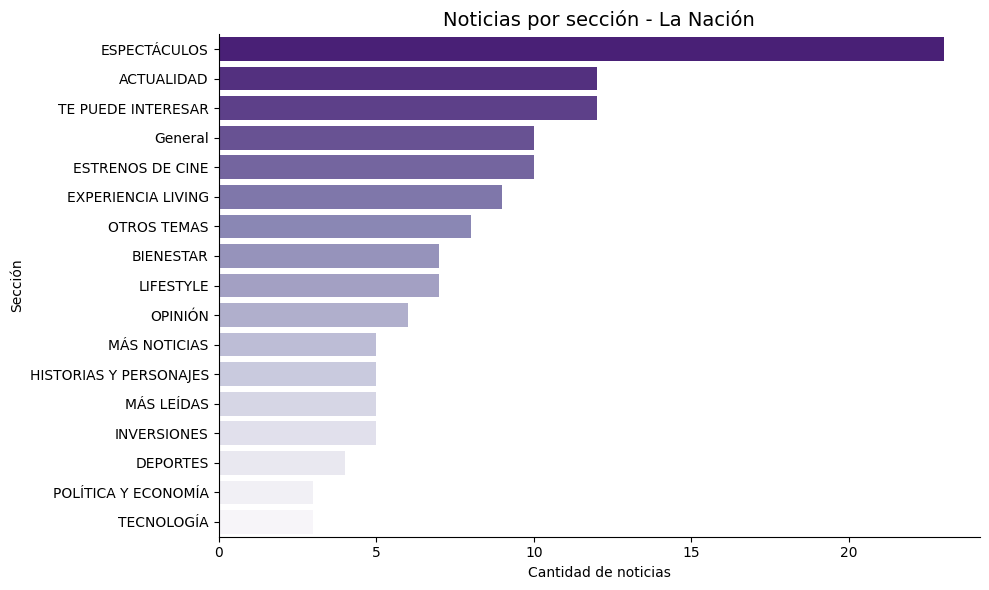

In [6]:
# EJERCICIO: Graficar las frecuencias de las secciones (Categoría) del conjunto de noticias.
import matplotlib.pyplot as plt
import seaborn as sns

#Contar noticias por sección (ignorando valores nulos)
conteo = df["seccion"].dropna().value_counts()

#Graficar
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=conteo.values, y=conteo.index, ax=ax, palette="Purples_r", hue=conteo.index, legend=False)

ax.set_title("Noticias por sección - La Nación", fontsize=14)
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("Sección")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



**Conclusion**


Se puede apreciar que la sección Espectáculos concentra la mayor cantidad de noticias en la portada, lo que refleja una clara prioridad editorial hacia el entretenimiento. En contraste, Tecnología y Política y Economía tienen la menor representación, lo que evidencia las decisiones de agendadel medio en esta edición.

## Consigna 3: Pesos del Lenguaje (Redes Léxicas)

Con la temática confirmada, deconstruiremos semánticamente esos focos de atención aislando el lenguaje que envuelve al contenido principal. Emplearemos el *Lollipop Chart* abordado en metodologías previas para proyectar las 15 palabras clave con mayor iteración masiva a lo largo de *toda la portada* titular.

Identifique las iteraciones que se formulan más allá de conectores y artículos nulos (*stop words*). ¿Cuál de estos nodos terminológicos monopoliza el marco informativo de la presente fecha?

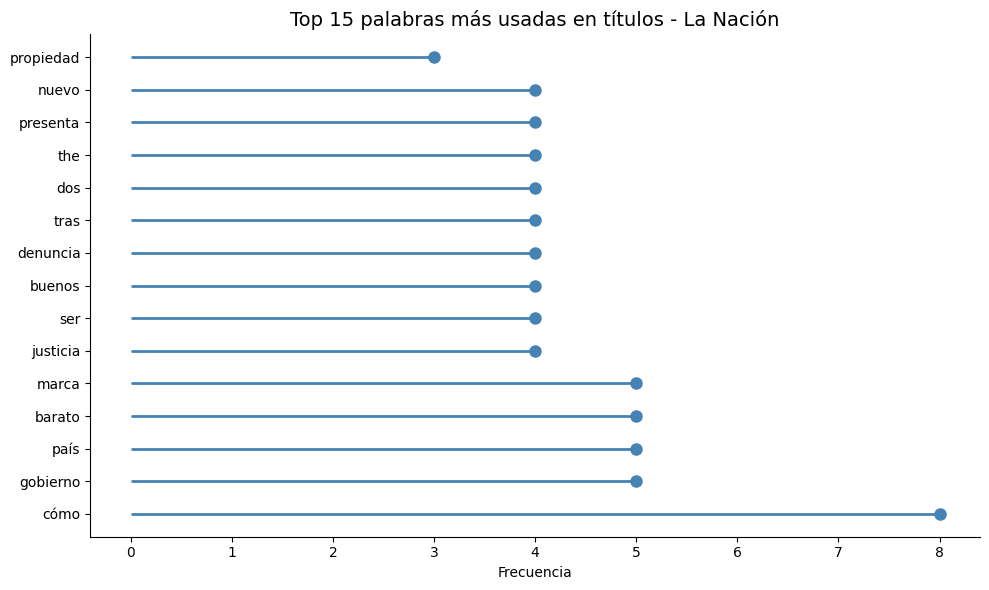

In [7]:
# EJERCICIO: Extraer el Top 15 de palabras más utilizadas en los títulos (ignorando stop words) y representarlas en un Lollipop Chart.
stopwords_es = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para", 
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este", 
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta", 
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni", 
    "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", "antes", "algunos", 
    "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes", 
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros", "mi", 
    "mis", "tú", "te", "ti", "tu", "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío", 
    "mía", "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas", "nuestro", 
    "nuestra", "nuestros", "nuestras", "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas", 
    "estoy", "estás", "está", "estamos", "estáis", "están", "esté", "estés", "estemos", "estéis", 
    "estén", "estaré", "estarás", "estará", "estaremos", "estaréis", "estarán", "estaría", "estarías", 
    "estaríamos", "estaríais", "estarían", "estaba", "estabas", "estábamos", "estabais", "estaban", 
    "estuve", "estuviste", "estuvo", "estuvimos", "estuvisteis", "estuvieron", "estuviera", "estuvieras", 
    "estuviéramos", "estuvierais", "estuvieran", "estuviese", "estuvieses", "estuviésemos", "estuvieseis", 
    "estuviesen", "estando", "estado", "estada", "estados", "estadas", "soy", "eres", "es", "somos", 
    "sois", "son", "sea", "seas", "seamos", "seáis", "sean", "seré", "serás", "será", "seremos", 
    "seréis", "serán", "sería", "serías", "seríamos", "seríais", "serían", "era", "eras", "éramos", 
    "erais", "eran", "fui", "fuiste", "fue", "fuimos", "fuisteis", "fueron", "fuera", "fueras", 
    "fuéramos", "fuerais", "fueran", "fuese", "fueses", "fuésemos", "fueseis", "fuesen", "siendo", 
    "sido", "tengo", "tienes", "tiene", "tenemos", "tenéis", "tienen", "tenga", "tengas", "tengamos", 
    "tengáis", "tengan", "tendré", "tendrás", "tendrá", "tendremos", "tendréis", "tendrán", "tendría", 
    "tendrías", "tendríamos", "tendríais", "tendrían", "tenía", "tenías", "teníamos", "teníais", 
    "tenían", "tuve", "tuviste", "tuvo", "tuvimos", "tuvisteis", "tuvieron", "tuviera", "tuvieras", 
    "tuviéramos", "tuvierais", "tuvieran", "tuviese", "tuvieses", "tuviésemos", "tuvieseis", 
    "tuviesen", "teniendo", "tenido", "tenida", "tenidos", "tenidas", "hubo"
}
from collections import Counter

# Unir todos los títulos en un solo texto
todos_los_titulos = " ".join(df["titulo"].dropna().str.lower())

# Separar en palabras y filtrar stopwords
palabras = [p for p in todos_los_titulos.split() if p not in stopwords_es and len(p) > 2]

# Contar y tomar el Top 15
top15 = Counter(palabras).most_common(15)
palabras_top, frecuencias = zip(*top15)

# Lollipop Chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.hlines(y=palabras_top, xmin=0, xmax=frecuencias, color="steelblue", linewidth=2)
ax.plot(frecuencias, palabras_top, "o", color="steelblue", markersize=8)

ax.set_title("Top 15 palabras más usadas en títulos - La Nación", fontsize=14)
ax.set_xlabel("Frecuencia")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


**Conclusion**


El análisis léxico revela que "cómo" es la palabra dominante con 8 apariciones, lo que indica una predominancia de títulos orientados al lifestyle y el contenido práctico, consistente con el liderazgo de la sección Espectáculos observado anteriormente. Le siguen términos como "gobierno" y "país", que reflejan una presencia menor pero significativa de la agenda política. La aparición de la palabra "the" en inglés sugiere títulos de entretenimiento o cultura pop. En conjunto, el vocabulario confirma una agenda editorial inclinada hacia el entretenimiento por encima de la información política o tecnológica.

## Consigna Final: Dashboard Dinámico de Sentido con Gradio

Integrar y escalar el diseño. Acaba de confirmar metodológicamente la agenda principal y el vocabulario dominador del periódico entero. Ahora envuélvalo funcionalmente convirtiéndolo en una Interface Web que logre desglosar el contenido respondiendo filtros particulares del investigador.

Deberá programar una Interfaz Gradio (`gr.Interface` o `gr.Blocks`) que exponga un **Desplegable (Dropdown)** poblado con las Secciones halladas (`Política`, `Economía`, `Sociedad`, etc.). 
La selección del usuario invocará una función que:
1. Cribe al DataFrame dejando solamente artículos pertenecientes a dicha sección.
2. Genere dos *outputs* (Salidas): 
    * Una tabla (`gr.Dataframe` o texto) enumerando puros títulos resultantes de esa sección selecta.
    * El gráfico del analizador de pesos (`Lollipop de frecuencias`) re-computado exclusivamente sobre el vocabulario de la sección elegida.

> Al correr la Interfaz, notará instantáneamente cómo el eje material y discursivo muta violentamente de polaridad con el simple acto interactivo de mover de 'Política' a 'Cultura'.

Defino la funcion

In [8]:
def analizar_seccion(seccion):
    df_filtrado = df[df["seccion"] == seccion]
    titulos = df_filtrado[["titulo"]].reset_index(drop=True)
    
    texto = " ".join(df_filtrado["titulo"].dropna().str.lower())
    palabras = [p for p in texto.split() if p not in stopwords_es and len(p) > 2]
    
    if len(palabras) == 0:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "Sin datos suficientes", ha="center")
        return titulos, fig
    
    top15 = Counter(palabras).most_common(15)
    palabras_top, frecuencias = zip(*top15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hlines(y=palabras_top, xmin=0, xmax=frecuencias, color="steelblue", linewidth=2)
    ax.plot(frecuencias, palabras_top, "o", color="steelblue", markersize=8)
    ax.set_title(f"Palabras más usadas en: {seccion}", fontsize=14)
    ax.set_xlabel("Frecuencia")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    
    return titulos, fig

Lista de secciones

In [9]:
secciones = sorted(df["seccion"].dropna().unique().tolist())

Interfaz gradio

In [11]:
import gradio as gr

with gr.Blocks() as demo:
    gr.Markdown("# Dashboard de Agenda Periodística - La Nación")
    dropdown = gr.Dropdown(choices=secciones, label="Seleccioná una sección")
    with gr.Row():
        tabla = gr.Dataframe(label="Títulos de la sección")
        grafico = gr.Plot(label="Palabras más usadas")
    dropdown.change(fn=analizar_seccion, inputs=dropdown, outputs=[tabla, grafico])

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
